# Expected revenue model :
### Emma and lucy 


#### import all necessary libraries


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split # splitting the dataset into training and testing sets
from sklearn.compose import ColumnTransformer # applying different transformations to different columns (numerical and categorical features)
from sklearn.pipeline import Pipeline # creating a pipeline to apply transformations and model training also in notes
from sklearn.preprocessing import OneHotEncoder # encoding categorical features
from sklearn.impute import SimpleImputer # imputation of missing values (numerical and categorical features)
# model libraries
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # mean absolute error for regression in lecture notes !!


In [4]:
from pathlib import Path
import pandas as pd

# go up 2 folders: expected_revenue → models → project root
BASE_DIR = Path.cwd().parents[1]

DATA_DIR = BASE_DIR / "data/data"

print("Base dir:", BASE_DIR)
print("Data dir:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

Base dir: c:\Users\Emma Davidson\ID5059\Coursework p2\Machine-Learning-Taxi-
Data dir: c:\Users\Emma Davidson\ID5059\Coursework p2\Machine-Learning-Taxi-\data\data
Exists: True


In [1]:
# Load the dataset
from pathlib import Path # this is for handling the data file paths in a more flexible way
BASE_DIR = Path.cwd().parents[1]
DATA_DIR = BASE_DIR / "data"

use_cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "fare_amount",
    "total_amount"
]

#### now we will try on all twelve months 

In [5]:
# Function above has the required parameters.
def load_data(month_start=1, month_end=12): # laoding all twelve months
    frames = []
    for month in range(month_start, month_end + 1):
        file_path = DATA_DIR / f"nyc_taxi_2024-{month:02d}.csv"
        print("Loading:", file_path.name)

        temp = pd.read_csv(
            file_path,
            usecols=use_cols,
            parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"]
        )
        temp["month"] = month
        frames.append(temp)

    return pd.concat(frames, ignore_index=True)

df = load_data(1, 12)
print(df.shape)

Loading: nyc_taxi_2024-01.csv
Loading: nyc_taxi_2024-02.csv
Loading: nyc_taxi_2024-03.csv
Loading: nyc_taxi_2024-04.csv
Loading: nyc_taxi_2024-05.csv
Loading: nyc_taxi_2024-06.csv
Loading: nyc_taxi_2024-07.csv
Loading: nyc_taxi_2024-08.csv
Loading: nyc_taxi_2024-09.csv
Loading: nyc_taxi_2024-10.csv
Loading: nyc_taxi_2024-11.csv
Loading: nyc_taxi_2024-12.csv
(41169720, 9)


#### Feature Engineering 

In [ ]:
df["trip_duration_minutes"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60 # converting to minutes

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour #extracting hour
df["pickup_dayofweek"] = df["tpep_pickup_datetime"].dt.dayofweek #monday=0, sunday=6
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month # extracting month
df["is_weekend"] = df["pickup_dayofweek"].isin([5, 6]).astype(int) # creating a binary feature for weekend (1 if weekend, 0 if weekday)

## ClEANING THE DATA - sups dups important 


In [7]:
df = df[
    (df["trip_distance"] > 0) &
    (df["trip_duration_minutes"] > 0) &
    (df["fare_amount"] > 0) &
    (df["total_amount"] > 0) &
    (df["trip_distance"] < 100) &
    (df["trip_duration_minutes"] < 300) &
    (df["fare_amount"] < 500)
].copy()

print(df.shape)

(39680443, 14)


### Aggrivating the months so that we see month trends



<Axes: xlabel='pickup_month'>

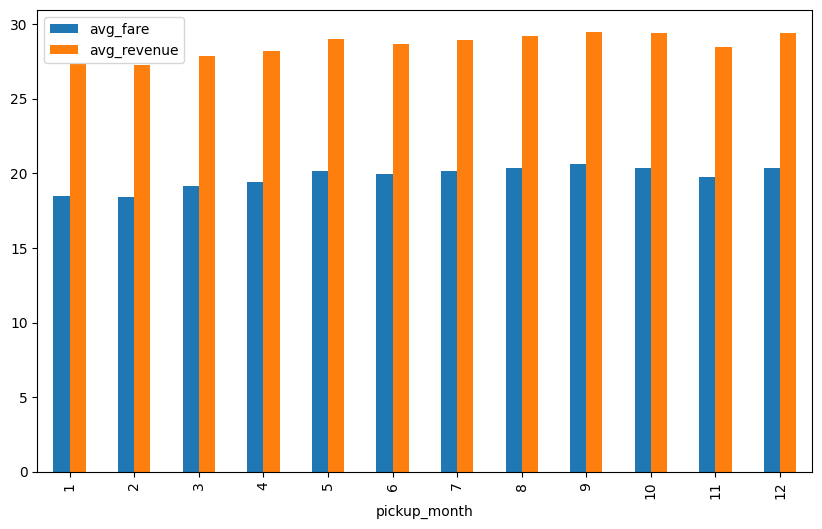

In [8]:
monthly = df.groupby("pickup_month").agg(
    avg_fare=("fare_amount", "mean"),
    avg_revenue=("total_amount", "mean"),
    trips=("fare_amount", "size")
).reset_index()

monthly.plot(x="pickup_month", y=["avg_fare", "avg_revenue"], kind="bar", figsize=(10, 6))

### Aggregating the whole features 

In [9]:
agg_features = (
    df.groupby(["PULocationID", "pickup_hour"])
      .agg(
          avg_fare_zone=("fare_amount", "mean"),
          avg_revenue_zone=("total_amount", "mean"),
          avg_distance_zone=("trip_distance", "mean")
      )
      .reset_index()
)

##### merge back into dataset

In [13]:
df = df.merge(
    agg_features,
    on=["PULocationID", "pickup_hour"],
    how="left"
)
print(df.shape)

(39680443, 23)


##### Quick mind check

In [20]:
print(X_train.isnull().sum().sort_values(ascending=False))

passenger_count          11489
trip_distance                0
trip_duration_minutes        0
pickup_hour                  0
pickup_month                 0
pickup_dayofweek             0
is_weekend                   0
avg_fare_zone                0
avg_revenue_zone             0
avg_distance_zone            0
dtype: int64


#### i forgot passager_count( fixing it now)


In [ ]:
df["passenger_count"] = df["passenger_count"].fillna(df["passenger_count"].median())

In [15]:
df_model = df.sample(n=150_000, random_state=42) # taking a random sample of 150,000 rows for modeling to reduce memory usage and speed up training
print(df_model.shape)

(150000, 23)


In [16]:
# Define the features and target variable
target = "total_amount"

features = [
    "trip_distance",
    "trip_duration_minutes",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "is_weekend",
    "passenger_count",
    "avg_fare_zone",
    "avg_revenue_zone",
    "avg_distance_zone"
]

#### Test Train Split - Lucy talked about wanting this a specific way talk to her

In [17]:
train = df_model[df_model["tpep_pickup_datetime"] < "2024-11-01"]
test = df_model[df_model["tpep_pickup_datetime"] >= "2024-11-01"]

X_train = train[features]
X_test = test[features]

y_train = train["total_amount"]
y_test = test["total_amount"]

#### Three Models - Linear Regression, Random Forst And Neural Network(simple MLP)

In [18]:

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    "Neural Network": MLPRegressor(
        hidden_layer_sizes=(32, 16),
        max_iter=100,
        random_state=42
    )
}

### Quick evaluation

In [19]:

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"\n{name}")
    print("MAE:", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2:", round(r2, 3))

    results[name] = rmse

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values